In [ ]:
# Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
# Loading dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns = data.feature_names)
df["target"] = data.target

print("Dataset loaded:")
print(df.head())

In [ ]:
# Basic info
print("\nDataset info:\n")
print(df.info())


Dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness

In [ ]:
print("\nDescriptive statistics:\n")
print(df.describe())


Descriptive statistics:

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000        

In [ ]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns = ["target"]))
df_scaled = pd.DataFrame(X_scaled, columns = data.feature_names)
df_scaled["target"] = df["target"]

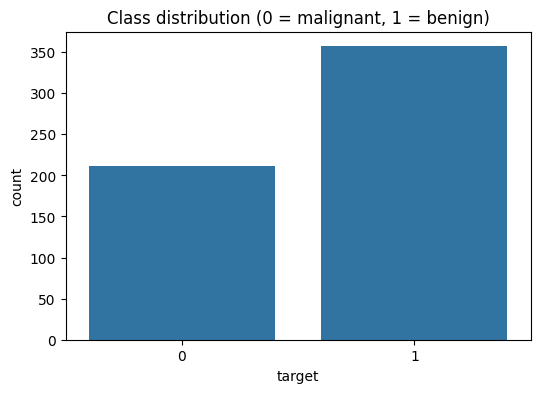

In [ ]:
# Simple visualization
plt.figure(figsize = (6, 4))
sns.countplot(x = df["target"])
plt.title("Class distribution (0 = malignant, 1 = benign)")
plt.show()

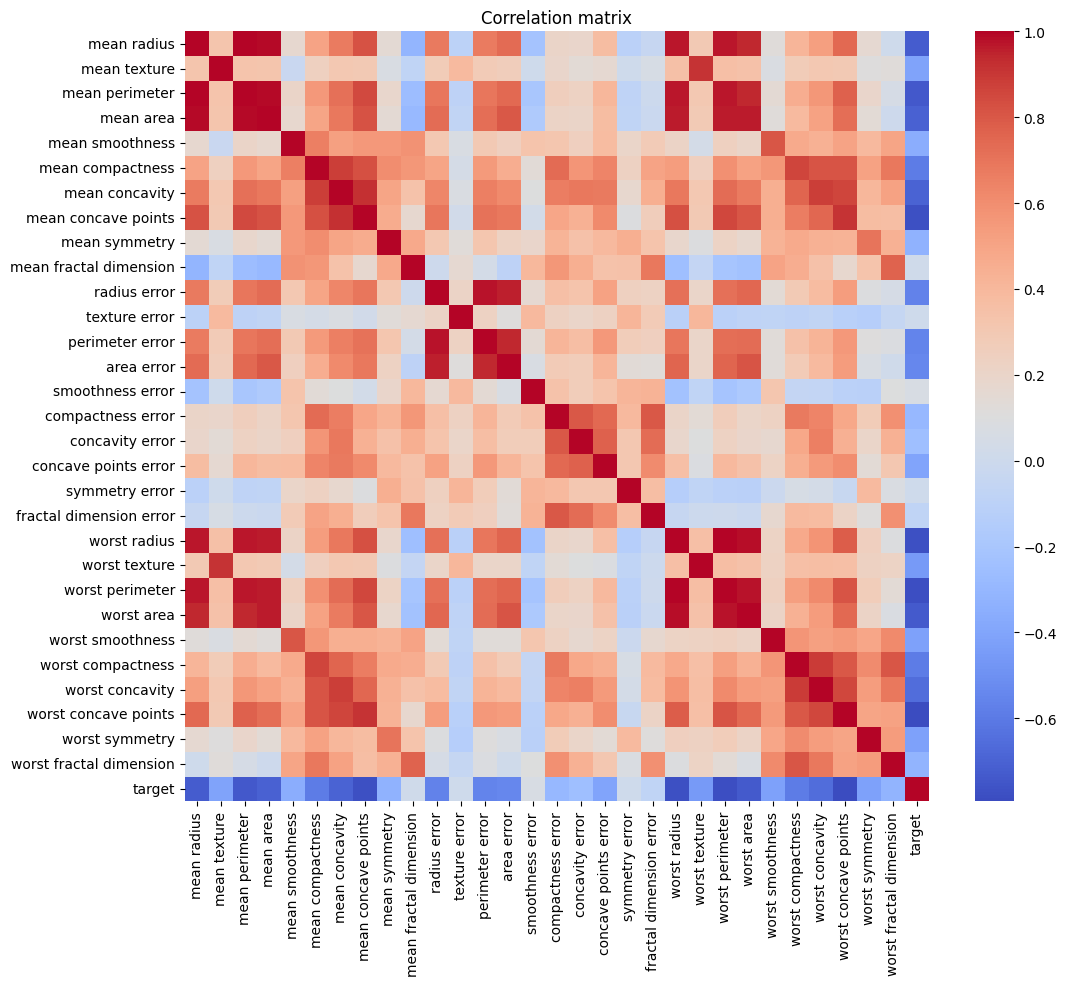

In [ ]:
# Correlation heatmap
plt.figure(figsize = (12, 10))
sns.heatmap(df_scaled.corr(), cmap = "coolwarm")
plt.title("Correlation matrix")
plt.show()

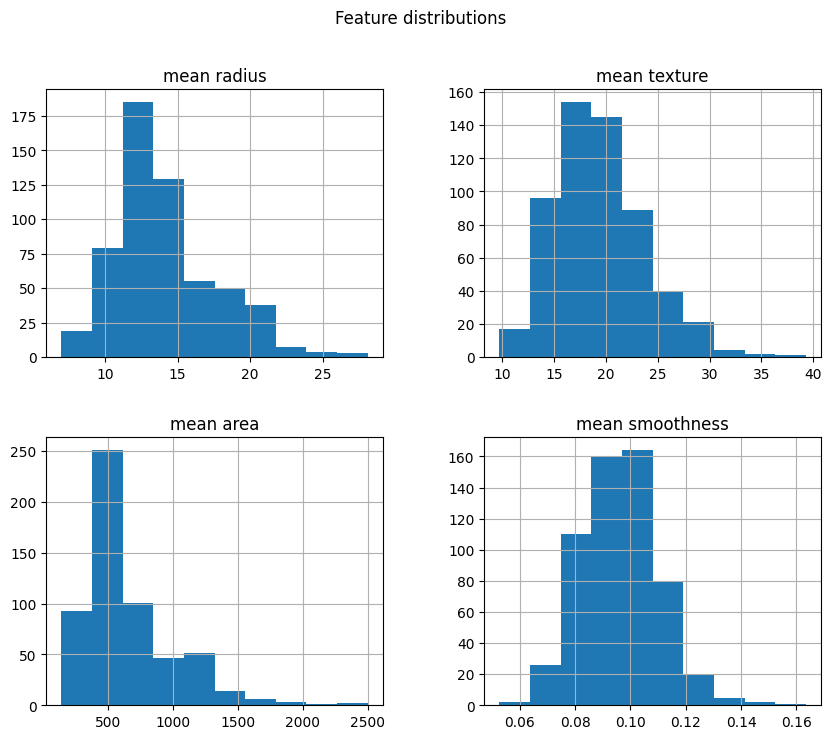

In [ ]:
# Histograms from other variables
cols = ["mean radius", "mean texture", "mean area", "mean smoothness"]

df[cols].hist(figsize = (10, 8))
plt.suptitle("Feature distributions")
plt.show()

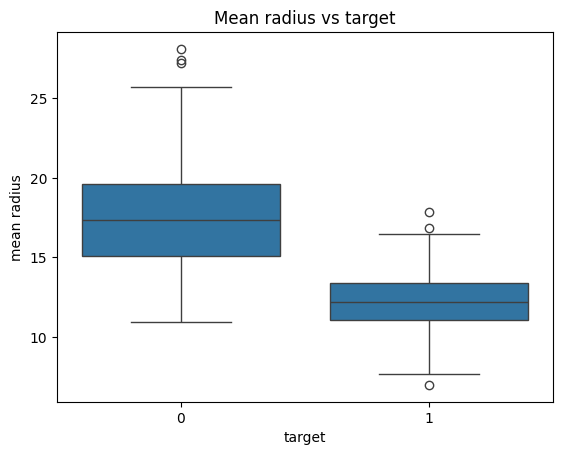

In [ ]:
# Variables & target relation
sns.boxplot(x = "target", y = "mean radius", data = df)
plt.title("Mean radius vs target")
plt.show()

In [ ]:
# Train / test split
X = df_scaled.drop(columns = ["target"])
y = df_scaled["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [ ]:
# Logistic Regression model
model = LogisticRegression(max_iter = 500)
model.fit(X_train, y_train)
preds = model.predict(X_test)

In [ ]:
# Results
print("\nModel accuracy: ", accuracy_score(y_test, preds))
print("\nConfusion matrix:\n")
print(confusion_matrix(y_test, preds))


Model accuracy:  0.9736842105263158

Confusion matrix:

[[41  2]
 [ 1 70]]
